In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from IPython.display import HTML

sys.path.append('../src')
import weather_utils
import plot_utils

%load_ext autoreload
%autoreload 2
%load_ext jupyter_black

In [2]:
fresh_pull = False
lat_range = (30.0, 50.0)
lon_range = (-120.0, -70.0)
start_date = "2025-11-01"
end_date = "2025-11-20"
variables = [
    "2m_temperature",
    "2m_dewpoint_temperature",
    "total_precipitation",
    "total_evaporation",
]
filename = (
    f"weather_data_lat_"
    f"{int(lat_range[0])}_{int(lat_range[1])}_"
    f"lon_{str(int(lon_range[0])).replace("-", "m")}_{str(int(lon_range[1])).replace("-", "m")}"
    f"_{start_date}_to_{end_date}"
)

if fresh_pull:
    weather_array = weather_utils.pull_era5_reanalysis(
        lat_range=lat_range,
        lon_range=lon_range,
        start_date=start_date,
        end_date=end_date,
        variables=variables,
        output_file=f"../resources/{filename}.nc",
    )
else:
    weather_array = xr.open_dataset(f"../resources/{filename}_extracted.nc")

# Create a new variable "t2m_C" using "t2m" and converting from Kelvin to Celsius and also change the units attribute accordingly
weather_array["t2m_C"] = weather_array["t2m"] - 273.15
weather_array["t2m_C"].attrs["units"] = "C"
weather_array["d2m_C"] = weather_array["d2m"] - 273.15
weather_array["d2m_C"].attrs["units"] = "C"

In [3]:
weather_array.data_vars.keys()

KeysView(Data variables:
    t2m      (valid_time, latitude, longitude) float32 8MB 274.4 274.4 ... nan
    d2m      (valid_time, latitude, longitude) float32 8MB 274.4 274.4 ... nan
    tp       (valid_time, latitude, longitude) float32 8MB ...
    e        (valid_time, latitude, longitude) float32 8MB ...
    t2m_C    (valid_time, latitude, longitude) float32 8MB 1.29 1.243 ... nan
    d2m_C    (valid_time, latitude, longitude) float32 8MB 1.26 1.206 ... nan)

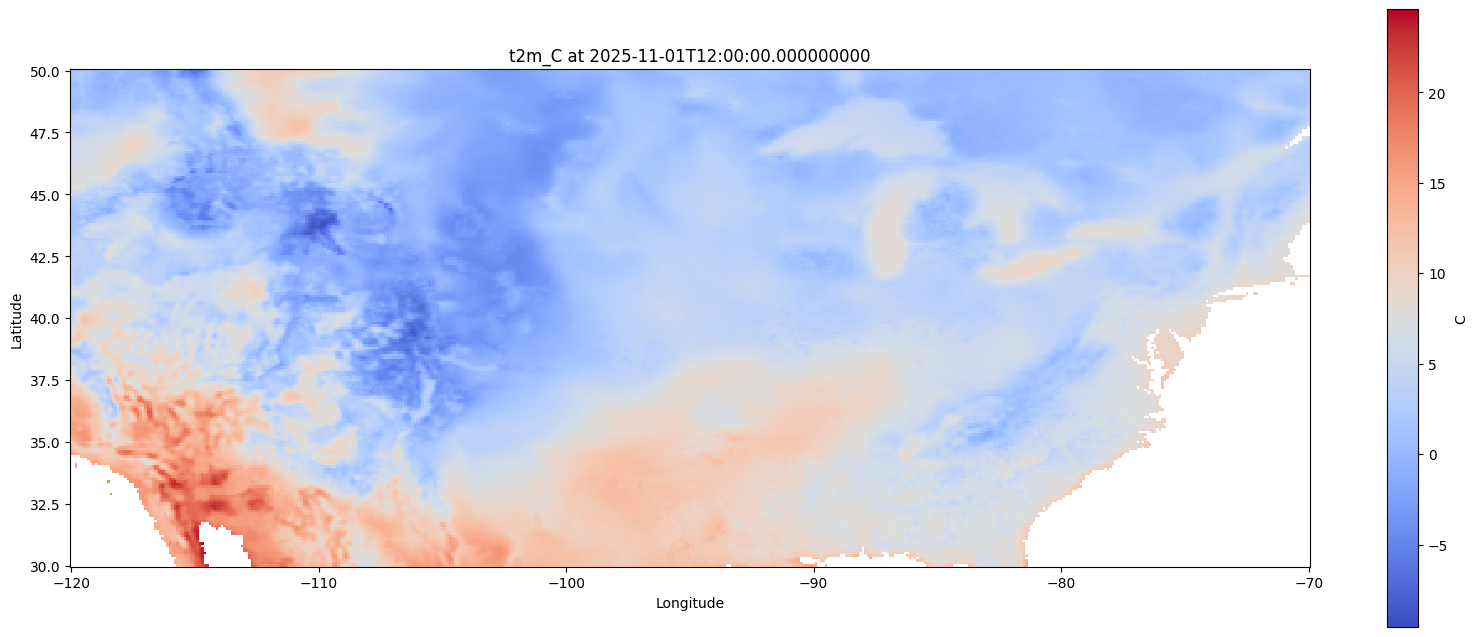

In [4]:
for time_idx in range(0, 1):
    plot_utils.plot_weather_data(
        weather_array=weather_array,
        weather_variable_name="t2m_C",
        time_idx=time_idx,
    )

In [5]:
weather_array["test_weather_score"] = weather_utils.weather_score_general(
    weather_variables_list=[weather_array["t2m_C"], weather_array["d2m_C"]],
    ideal_values_list=[10.0, 0.0],
    widths_list=[10.0, 10.0],
)

In [6]:
weather_array = weather_utils.apply_formula_to_weather_variables(
    weather_array=weather_array,
    formula=weather_utils.weather_score,
    formula_kwargs={
        "t2m_ideal_c": 10.0,
        "d2m_ideal_c": 0.0,
        "t2m_width_c": 10.0,
        "d2m_width_c": 10.0,
    },
    new_variable_name="test_weather_score",
)

In [7]:
weather_array.data_vars.keys()

KeysView(Data variables:
    t2m                 (valid_time, latitude, longitude) float32 8MB 274.4 ....
    d2m                 (valid_time, latitude, longitude) float32 8MB 274.4 ....
    tp                  (valid_time, latitude, longitude) float32 8MB ...
    e                   (valid_time, latitude, longitude) float32 8MB ...
    t2m_C               (valid_time, latitude, longitude) float32 8MB 1.29 .....
    d2m_C               (valid_time, latitude, longitude) float32 8MB 1.26 .....
    test_weather_score  (valid_time, latitude, longitude) float32 8MB 0.4609 ...)

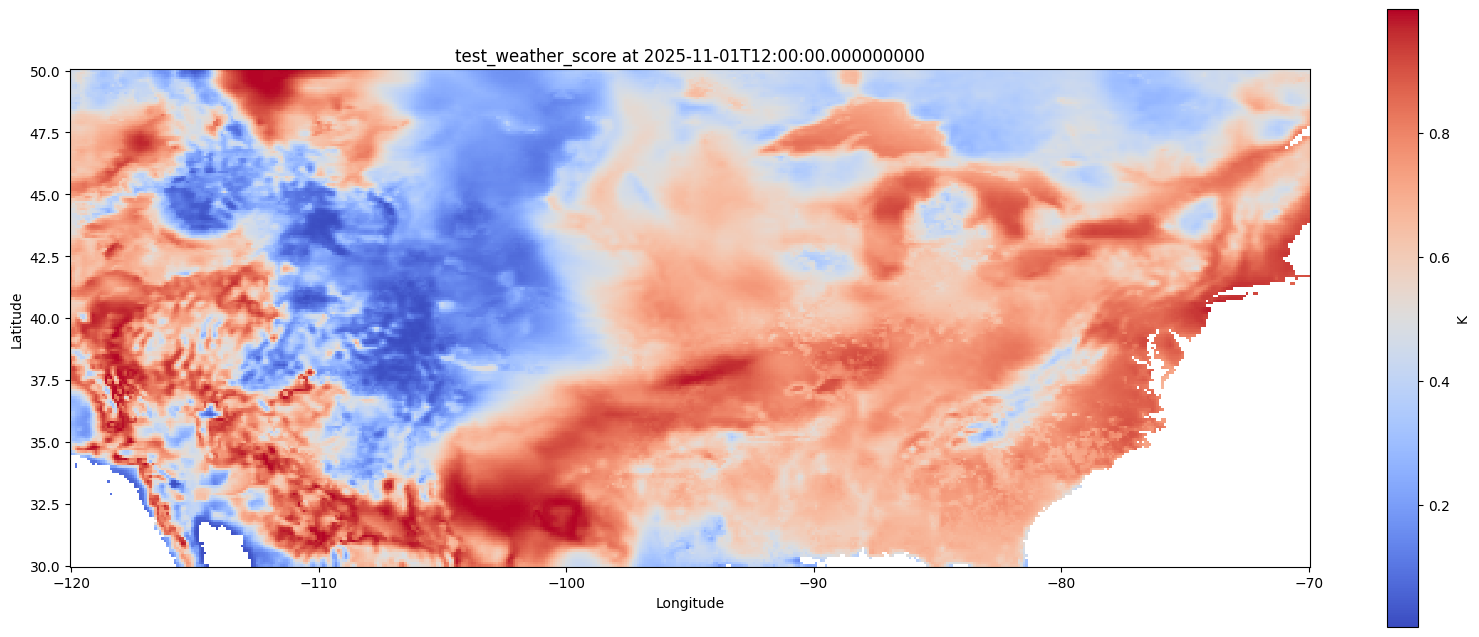

In [15]:
plot_utils.plot_weather_data(
    weather_array=weather_array,
    weather_variable_name="test_weather_score",
    time_idx=0,
)

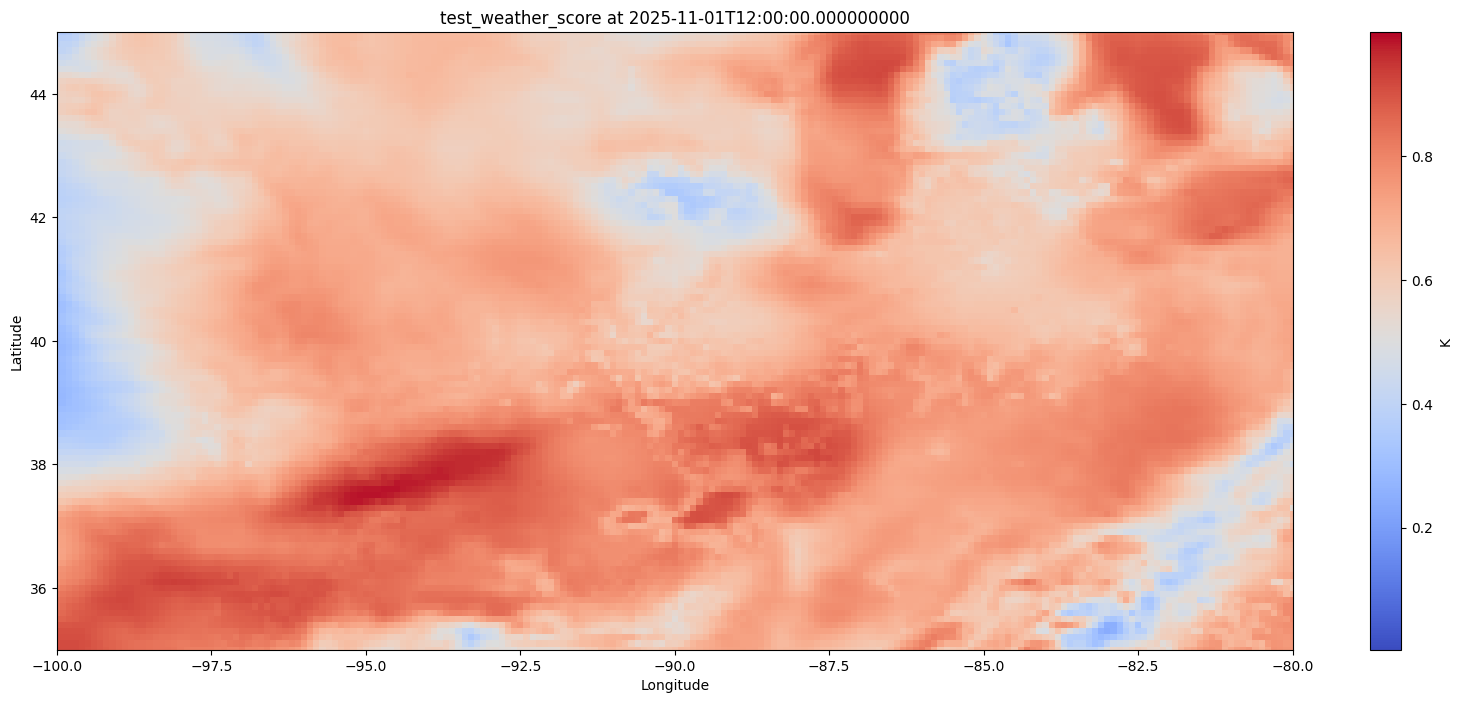

In [16]:
# An example of zoomed in map plot
plot_utils.plot_weather_data(
    weather_array=weather_array,
    weather_variable_name="test_weather_score",
    time_idx=0,
    latitude_range=(35.0, 45.0),
    longitude_range=(-100.0, -80.0),
)

In [13]:
animated_object = plot_utils.animate_weather_data(
    weather_array=weather_array,
    weather_variable_name="test_weather_score",
    time_range=(0, 19),
    interval=500,
    output_filepath=None,  # "../resources/weather_animation_test_weather_score_2025_11_01_to_2025_11_20.mp4",
)

HTML(animated_object.to_jshtml())